In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/Porfolio/Balearia/2 Demanda"

# Creamos estructura del proyecto
os.makedirs(f"{PROJECT_ROOT}/data/raw", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/data/processed", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/reports/figures", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/reports/model_cards", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/dashboards/powerbi_mockups", exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Exists?:", os.path.exists(PROJECT_ROOT))
print("Processed folder:", os.path.exists(f"{PROJECT_ROOT}/data/processed"))

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/Porfolio/Balearia/2 Demanda
Exists?: True
Processed folder: True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_store = pd.read_parquet(f"{PROJECT_ROOT}/data/processed/trip_feature_store.parquet")

feature_store["departure_datetime_local"] = pd.to_datetime(feature_store["departure_datetime_local"])
feature_store["date"] = pd.to_datetime(feature_store["date"])

weekday_names = ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]

print("Rows:", feature_store.shape[0])
print("Date range:", feature_store["date"].min().date(), "→", feature_store["date"].max().date())
feature_store.head()

Rows: 8868
Date range: 2024-01-07 → 2025-12-31


,company,trip_id,route_id,origin_port,dest_port,departure_datetime_local,date,dep_time,weekday,month,...,pax_lag_1w,pax_lag_2w,veh_lag_1w,veh_lag_2w,pax_roll_mean_20,pax_roll_std_20,veh_roll_mean_20,veh_roll_std_20,delay_roll_mean_20,occ_pax_roll_mean_20
0,LevanteFerries,T0000075,DEN-FOR,Denia,Formentera,2024-01-07 08:00:00,2024-01-07,08:00,6,1,...,542.0,533.0,194.0,160.0,581.25,157.994295,173.80,44.684390,5.60,0.645833
1,LevanteFerries,T0000076,DEN-FOR,Denia,Formentera,2024-01-07 12:00:00,2024-01-07,12:00,6,1,...,631.0,528.0,214.0,162.0,587.10,156.085638,175.95,43.950301,5.60,0.652333
2,LevanteFerries,T0000077,DEN-FOR,Denia,Formentera,2024-01-07 17:00:00,2024-01-07,17:00,6,1,...,591.0,399.0,168.0,114.0,585.10,155.248494,174.35,43.221918,6.40,0.650111
3,LevanteFerries,T0000078,DEN-FOR,Denia,Formentera,2024-01-07 20:00:00,2024-01-07,20:00,6,1,...,733.0,393.0,192.0,142.0,588.70,155.762674,173.30,43.510555,5.75,0.654111
4,LevanteFerries,T0000089,DEN-FOR,Denia,Formentera,2024-01-08 08:00:00,2024-01-08,08:00,0,1,...,872.0,474.0,301.0,122.0,601.20,156.441211,177.30,42.798303,5.75,0.501000


In [3]:
route_kpis = (
    feature_store.groupby("route_id")
    .agg(
        trips=("trip_id","count"),
        pax_mean=("pax_real","mean"),
        pax_std=("pax_real","std"),
        occ_mean=("occupancy_real_pax","mean"),
        occ_p90=("occupancy_real_pax", lambda x: float(np.quantile(x, 0.90))),
        price_mean=("avg_ticket_price","mean"),
        sea_bad_rate=("sea_bad_proxy","mean"),
        delay_mean=("delay_minutes","mean"),
        revenue_mean=("revenue_real","mean"),
    )
    .sort_values("pax_mean", ascending=False)
)

display(route_kpis)
route_kpis.to_csv(f"{PROJECT_ROOT}/reports/route_kpis_summary.csv")
print("Saved ✅ reports/route_kpis_summary.csv")

,trips,pax_mean,pax_std,occ_mean,occ_p90,price_mean,sea_bad_rate,delay_mean,revenue_mean
route_id,,,,,,,,,
DEN-IBZ,2556,758.546557,160.070038,0.755962,1.000000,53.290872,0.127934,7.390454,48137.544169
DEN-FOR,2556,665.844288,155.919915,0.662608,0.929444,53.255390,0.127934,7.275039,42585.778588
DEN-PMI,1878,638.820554,163.624241,0.532350,0.729167,47.362178,0.125133,7.360490,36691.408811
VAL-IBZ,1878,517.416400,132.593342,0.431180,0.581667,47.275124,0.125133,7.320021,29696.308532


Saved ✅ reports/route_kpis_summary.csv


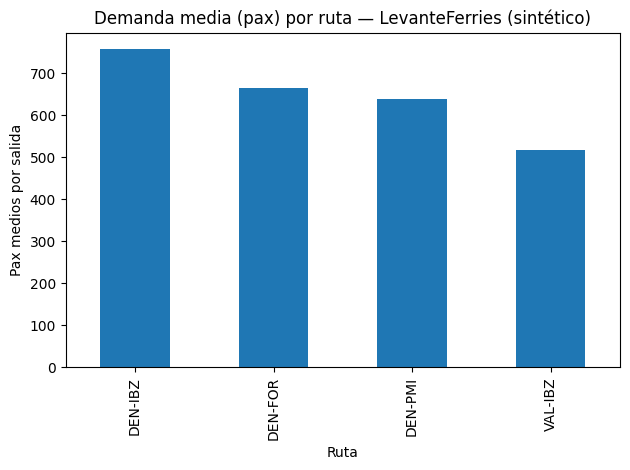

Saved ✅ eda_01_pax_by_route.png


In [4]:
pax_by_route = feature_store.groupby("route_id")["pax_real"].mean().sort_values(ascending=False)

plt.figure()
pax_by_route.plot(kind="bar")
plt.title("Demanda media (pax) por ruta — LevanteFerries (sintético)")
plt.xlabel("Ruta")
plt.ylabel("Pax medios por salida")
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/reports/figures/eda_01_pax_by_route.png", dpi=150)
plt.show()

print("Saved ✅ eda_01_pax_by_route.png")

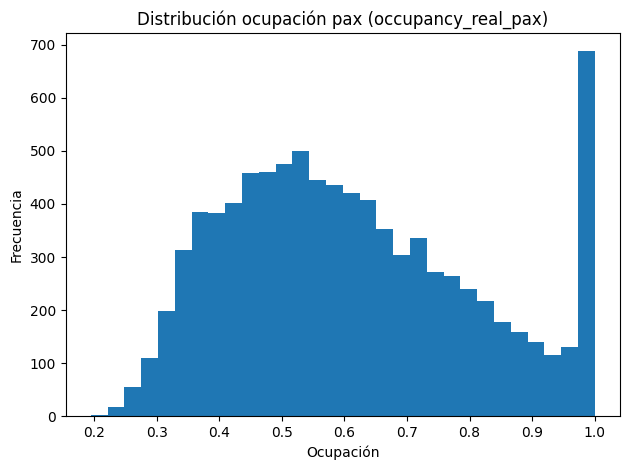

Saved ✅ eda_02_occupancy_hist.png


In [5]:
plt.figure()
plt.hist(feature_store["occupancy_real_pax"], bins=30)
plt.title("Distribución ocupación pax (occupancy_real_pax)")
plt.xlabel("Ocupación")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/reports/figures/eda_02_occupancy_hist.png", dpi=150)
plt.show()

print("Saved ✅ eda_02_occupancy_hist.png")

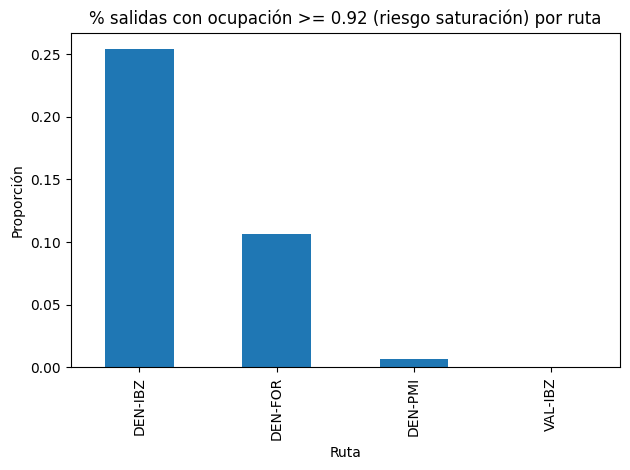

,saturation_rate
route_id,
DEN-IBZ,0.254304
DEN-FOR,0.106416
DEN-PMI,0.006390
VAL-IBZ,0.000000


Saved ✅ eda_03_saturation_rate_by_route.png


In [6]:
risk_sat = (
    feature_store.assign(is_sat = feature_store["occupancy_real_pax"] >= 0.92)
    .groupby("route_id")["is_sat"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
risk_sat.plot(kind="bar")
plt.title("% salidas con ocupación >= 0.92 (riesgo saturación) por ruta")
plt.xlabel("Ruta")
plt.ylabel("Proporción")
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/reports/figures/eda_03_saturation_rate_by_route.png", dpi=150)
plt.show()

display(risk_sat.to_frame("saturation_rate"))
print("Saved ✅ eda_03_saturation_rate_by_route.png")

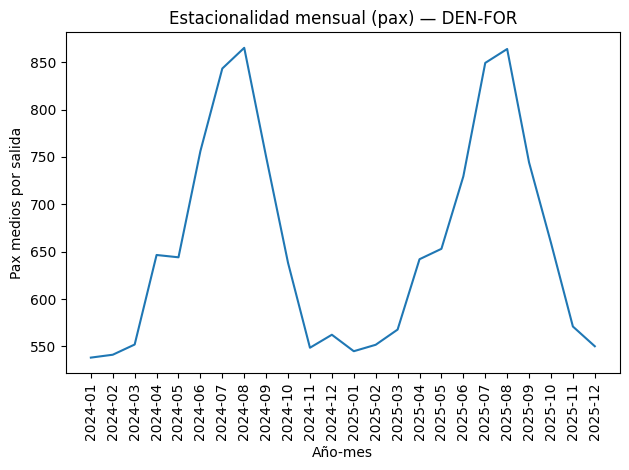

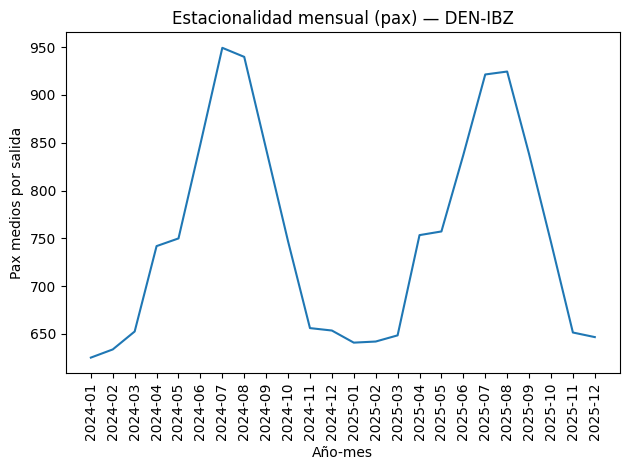

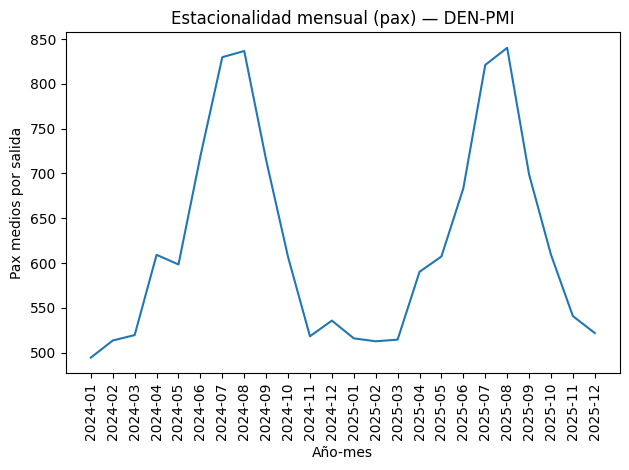

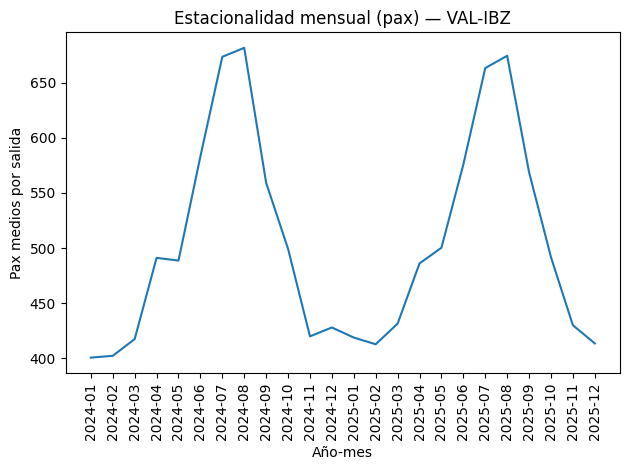

Saved ✅ eda_04_monthly_seasonality_<route>.png


In [7]:
monthly = (
    feature_store.groupby(["route_id","year","month"])["pax_real"]
    .mean()
    .reset_index()
)
monthly["year_month"] = monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)

for route in monthly["route_id"].unique():
    m = monthly[monthly["route_id"] == route].copy()

    plt.figure()
    plt.plot(m["year_month"], m["pax_real"])
    plt.xticks(rotation=90)
    plt.title(f"Estacionalidad mensual (pax) — {route}")
    plt.xlabel("Año-mes")
    plt.ylabel("Pax medios por salida")
    plt.tight_layout()
    plt.savefig(f"{PROJECT_ROOT}/reports/figures/eda_04_monthly_seasonality_{route}.png", dpi=150)
    plt.show()

print("Saved ✅ eda_04_monthly_seasonality_<route>.png")

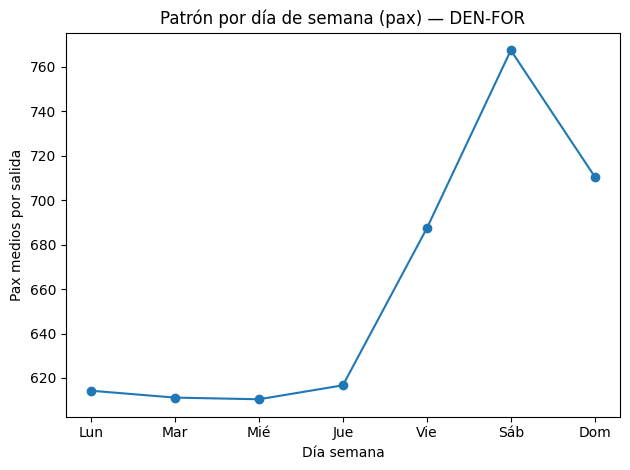

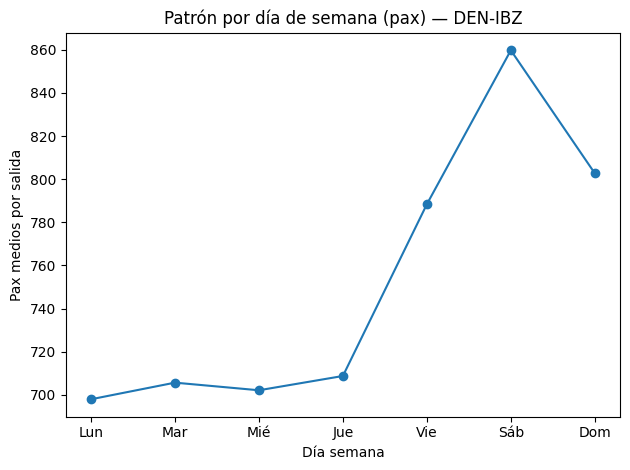

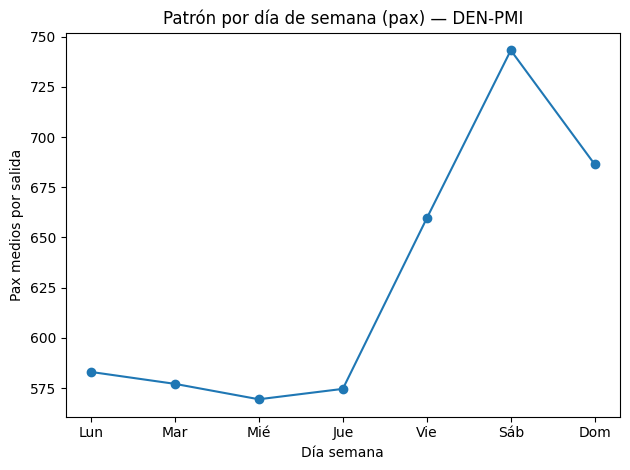

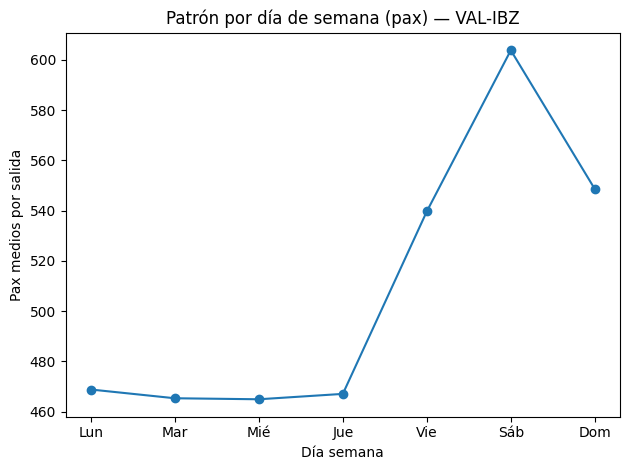

Saved ✅ eda_05_weekday_pattern_<route>.png


In [8]:
dow = (
    feature_store.groupby(["route_id","weekday"])["pax_real"]
    .mean()
    .reset_index()
)

for route in dow["route_id"].unique():
    d = dow[dow["route_id"] == route].sort_values("weekday")

    plt.figure()
    plt.plot(d["weekday"], d["pax_real"], marker="o")
    plt.xticks(d["weekday"], [weekday_names[i] for i in d["weekday"]])
    plt.title(f"Patrón por día de semana (pax) — {route}")
    plt.xlabel("Día semana")
    plt.ylabel("Pax medios por salida")
    plt.tight_layout()
    plt.savefig(f"{PROJECT_ROOT}/reports/figures/eda_05_weekday_pattern_{route}.png", dpi=150)
    plt.show()

print("Saved ✅ eda_05_weekday_pattern_<route>.png")

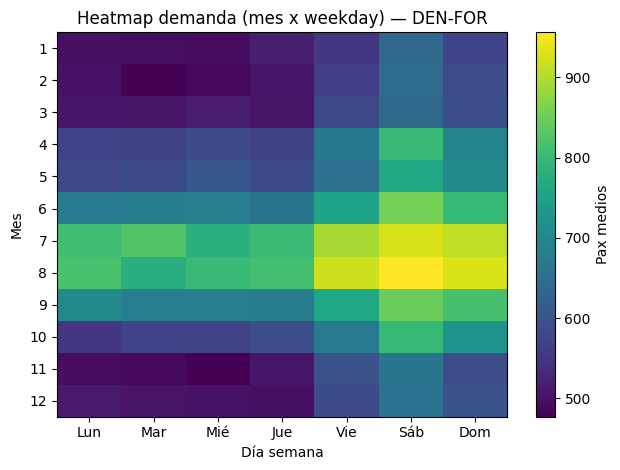

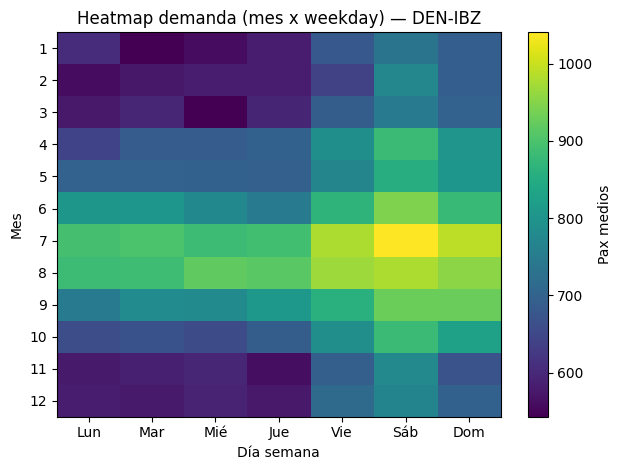

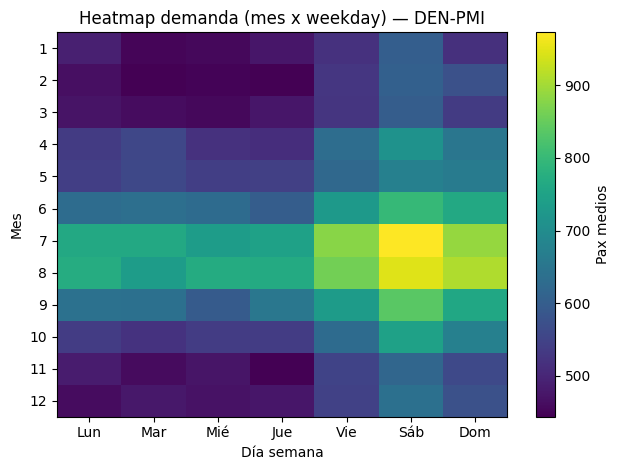

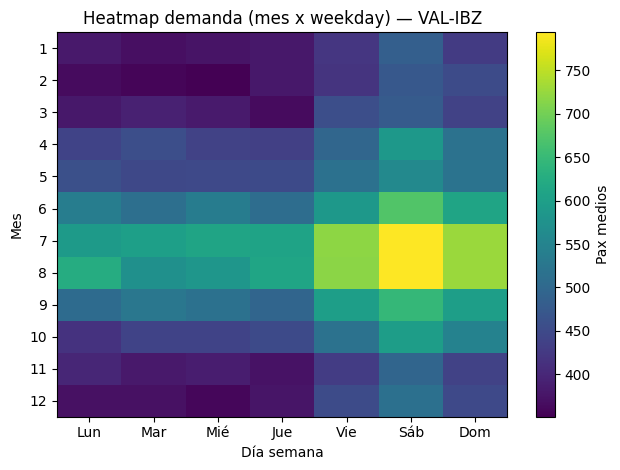

Saved ✅ eda_06_heatmap_<route>.png


In [9]:
def heatmap_month_weekday(df, route_id):
    data = df[df["route_id"] == route_id].copy()
    pivot = data.pivot_table(index="month", columns="weekday", values="pax_real", aggfunc="mean")
    pivot = pivot.reindex(index=range(1,13), columns=range(0,7))

    plt.figure()
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="Pax medios")
    plt.title(f"Heatmap demanda (mes x weekday) — {route_id}")
    plt.yticks(range(12), range(1,13))
    plt.xticks(range(7), weekday_names)
    plt.xlabel("Día semana")
    plt.ylabel("Mes")
    plt.tight_layout()
    plt.savefig(f"{PROJECT_ROOT}/reports/figures/eda_06_heatmap_{route_id}.png", dpi=150)
    plt.show()

for r in feature_store["route_id"].unique():
    heatmap_month_weekday(feature_store, r)

print("Saved ✅ eda_06_heatmap_<route>.png")

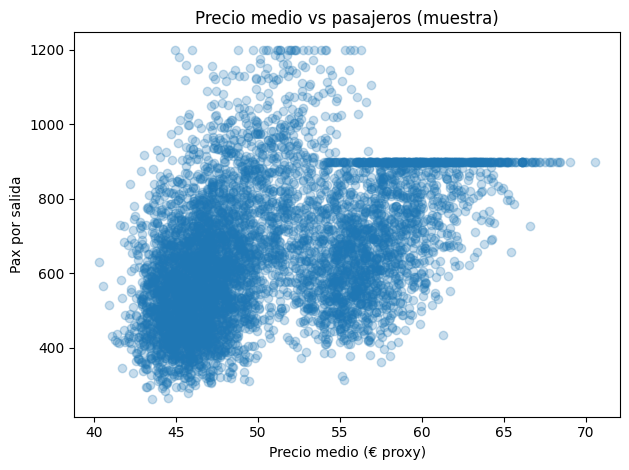

Correlación (precio vs pax): 0.43
Saved ✅ eda_07_price_vs_pax.png


In [10]:
sample = feature_store.sample(min(6000, len(feature_store)), random_state=42)

plt.figure()
plt.scatter(sample["avg_ticket_price"], sample["pax_real"], alpha=0.25)
plt.title("Precio medio vs pasajeros (muestra)")
plt.xlabel("Precio medio (€ proxy)")
plt.ylabel("Pax por salida")
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/reports/figures/eda_07_price_vs_pax.png", dpi=150)
plt.show()

corr = sample[["avg_ticket_price","pax_real"]].corr().iloc[0,1]
print("Correlación (precio vs pax):", round(float(corr), 3))
print("Saved ✅ eda_07_price_vs_pax.png")

In [11]:
sea_effect = (
    feature_store.groupby(["route_id","sea_bad_proxy"])["pax_real"]
    .mean()
    .reset_index()
)

display(sea_effect)

sea_effect.to_csv(f"{PROJECT_ROOT}/reports/sea_effect_by_route.csv", index=False)
print("Saved ✅ reports/sea_effect_by_route.csv")

,route_id,sea_bad_proxy,pax_real
0,DEN-FOR,0,682.223419
1,DEN-FOR,1,554.195719
2,DEN-IBZ,0,775.358905
3,DEN-IBZ,1,643.944954
4,DEN-PMI,0,653.999391
5,DEN-PMI,1,532.697872
6,VAL-IBZ,0,530.231284
7,VAL-IBZ,1,427.821277


Saved ✅ reports/sea_effect_by_route.csv


In [12]:
top_demand_routes = (feature_store.groupby("route_id")["pax_real"].mean().sort_values(ascending=False).head(2)).index.tolist()
top_sat_routes = (risk_sat.sort_values(ascending=False).head(2)).index.tolist()

insights = {
    "top_routes_by_avg_demand": top_demand_routes,
    "top_routes_by_saturation_risk": top_sat_routes,
    "global_avg_occupancy": float(feature_store["occupancy_real_pax"].mean()),
    "global_sea_bad_rate": float(feature_store["sea_bad_proxy"].mean()),
    "global_avg_price": float(feature_store["avg_ticket_price"].mean()),
}

insights_df = pd.DataFrame([insights])
display(insights_df)

insights_df.to_csv(f"{PROJECT_ROOT}/reports/eda_key_insights.csv", index=False)
print("Saved ✅ reports/eda_key_insights.csv")

,top_routes_by_avg_demand,top_routes_by_saturation_risk,global_avg_occupancy,global_sea_bad_rate,global_avg_price
0,"[DEN-IBZ, DEN-FOR]","[DEN-IBZ, DEN-FOR]",0.61292,0.126748,50.751139


Saved ✅ reports/eda_key_insights.csv
